In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Can change to read another root file
RESULT_DIR = PROJECT_ROOT / "data/metadata/full_mmd"

#### đọc toàn bộ thông tin

In [22]:
if not RESULT_DIR.is_dir():
    raise FileNotFoundError(f"Không tìm thấy thư mục kết quả: {RESULT_DIR}")

FILE_ROLES = {
    "rq1_metric_summary": "Mean/std source-only",
    "rq1_per_seed_metrics": "Source-only theo seed",
    "rq1_gap_summary": "Domain gap tổng hợp",
    "rq1_gap_per_seed": "Domain gap theo seed",
    "rq2_metric_summary": "Mean/std source-only và MMD",
    "rq2_per_seed_metrics": "Metric MMD theo seed",
    "rq2_adaptation_gain_summary": "MMD gain tổng hợp",
    "rq2_adaptation_gain_per_seed": "MMD gain theo seed",
    "rq2_domain_diagnostics_summary": "MMD²/domain AUC tổng hợp",
    "rq2_domain_diagnostics_per_seed": "MMD²/domain AUC theo seed",
    "rq2_learning_curves": "Loss và validation PR-AUC",
}

tables = {path.stem: pd.read_csv(path) for path in sorted(RESULT_DIR.glob("*.csv"))}
configs = {path.stem: json.loads(path.read_text()) for path in sorted(RESULT_DIR.glob("*.json"))}
other_files = sorted([*RESULT_DIR.glob("*.md"), *RESULT_DIR.glob("*.joblib")])

inventory = pd.DataFrame([
    {"file": f"{name}.csv", "role": FILE_ROLES.get(name, "CSV khác"),
     "rows": len(table), "columns": len(table.columns)}
    for name, table in tables.items()
] + [
    {"file": f"{name}.json", "role": "Run configuration", "rows": 1, "columns": None}
    for name in configs
] + [
    {"file": path.name, "role": "Tài liệu/model", "rows": None, "columns": None}
    for path in other_files
])

print(f"Đang đọc: {RESULT_DIR}")
display(inventory)
if tables:
    first_table = next(iter(tables))

Đang đọc: /Users/thonph/Desktop/KLTN/data/metadata/full_mmd


,file,role,rows,columns
0,rq2_adaptation_gain_per_seed.csv,MMD gain theo seed,10.0,34.0
1,rq2_adaptation_gain_summary.csv,MMD gain tổng hợp,2.0,26.0
2,rq2_domain_diagnostics_per_seed.csv,MMD²/domain AUC theo seed,20.0,10.0
3,rq2_domain_diagnostics_summary.csv,MMD²/domain AUC tổng hợp,4.0,10.0
4,rq2_learning_curves.csv,Loss và validation PR-AUC,850.0,8.0
5,rq2_metric_summary.csv,Mean/std source-only và MMD,8.0,24.0
6,rq2_per_seed_metrics.csv,Metric MMD theo seed,40.0,28.0
7,rq2_run_config.json,Run configuration,1.0,NaN
8,FULL_MMD_REPORT.md,Tài liệu/model,NaN,NaN


## 2. Cấu hình lần chạy

In [23]:
if configs:
    run_config_name = next(iter(configs))
    run_config = configs[run_config_name]
    print(json.dumps(run_config, indent=2, ensure_ascii=False))
else:
    print("Thư mục này không có run config JSON.")

{
  "experiment": "source-only versus marginal single-kernel MMD",
  "protocol": {
    "split_directory": "data/splits_full",
    "duplicate_control": "canonical stratified-grouped split",
    "preprocessing_fit": "source train only",
    "classification_labels": "source train only",
    "unlabeled_adaptation_data": "target train features only",
    "source_validation_role": "early stopping by source PR-AUC",
    "threshold_selection": "maximize F1 on source validation",
    "target_validation_role": "unused",
    "source_test_role": "within-domain evaluation only",
    "target_test_role": "final cross-domain evaluation only",
    "target_labels_used_for_training_or_selection": false,
    "seeds": [
      42,
      43,
      44,
      45,
      46
    ],
    "paired_control": "same PyTorch MLP initialization and source batches; lambda=0 versus lambda>0"
  },
  "mmd": {
    "variant": "marginal single-RBF MMD",
    "training_estimator": "linear-time unbiased",
    "diagnostic_estimator"

## 3. Metric chính

,direction,method,evaluation_domain,evaluation_dataset,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,recall_mean,precision_mean
0,unsw_to_cicids,source_only,within_domain,UNSW-NB15,0.981301,0.009794,0.997891,0.000969,0.953865,0.975537,0.933480
1,unsw_to_cicids,source_only,cross_domain,CICIDS2017,0.292970,0.096101,0.499506,0.039029,0.172973,0.204383,0.150079
2,unsw_to_cicids,mmd,within_domain,UNSW-NB15,0.988380,0.006065,0.998590,0.000810,0.956374,0.971614,0.942021
3,unsw_to_cicids,mmd,cross_domain,CICIDS2017,0.302256,0.113362,0.487864,0.034739,0.188545,0.209709,0.174281
4,cicids_to_unsw,source_only,within_domain,CICIDS2017,0.993647,0.000760,0.998285,0.000167,0.963738,0.972539,0.955198
5,cicids_to_unsw,source_only,cross_domain,UNSW-NB15,0.245375,0.057148,0.642190,0.094355,0.006109,0.003108,0.571650
6,cicids_to_unsw,mmd,within_domain,CICIDS2017,0.994118,0.000782,0.998376,0.000240,0.964806,0.968548,0.961334
7,cicids_to_unsw,mmd,cross_domain,UNSW-NB15,0.257675,0.148439,0.581110,0.154128,0.006197,0.003138,0.528787


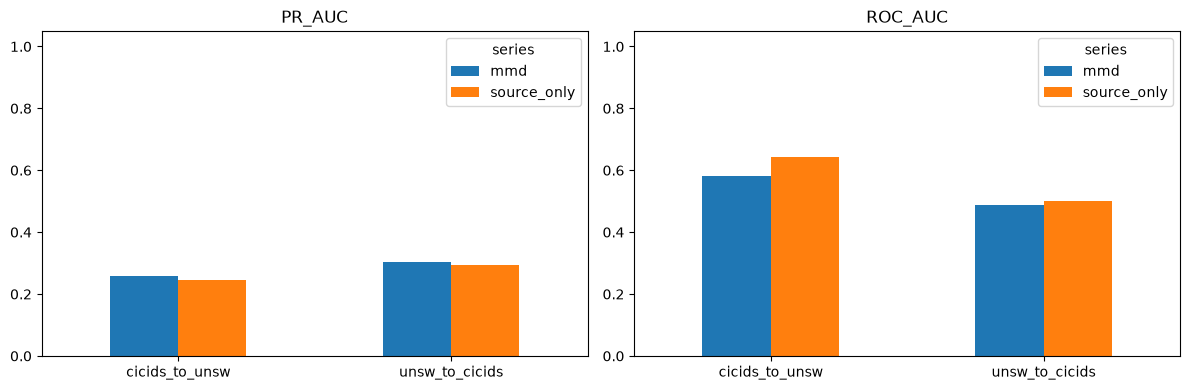

In [18]:
metric_table_name = next(
    (name for name in ("rq2_metric_summary", "rq1_metric_summary") if name in tables),
    None,
)
if metric_table_name is None:
    print("Không có metric summary trong thư mục này.")
else:
    metric_summary = tables[metric_table_name]
    wanted = [
        "direction", "method", "evaluation_domain", "evaluation_dataset",
        "pr_auc_mean", "pr_auc_std", "roc_auc_mean", "roc_auc_std",
        "f1_mean", "recall_mean", "precision_mean",
    ]
    display(metric_summary[[column for column in wanted if column in metric_summary]].round(6))

    chart_data = metric_summary.copy()
    if "method" in chart_data:
        chart_data = chart_data.loc[chart_data["evaluation_domain"].eq("cross_domain")]
        chart_data["series"] = chart_data["method"]
    else:
        chart_data["series"] = chart_data["evaluation_domain"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for metric, ax in zip(("pr_auc_mean", "roc_auc_mean"), axes):
        chart_data.pivot(index="direction", columns="series", values=metric).plot(
            kind="bar", ax=ax
        )
        ax.set_title(metric.replace("_mean", "").upper())
        ax.set_xlabel("")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

## 4. Gain và domain diagnostics

In [19]:
if "rq2_adaptation_gain_summary" in tables:
    gains = tables["rq2_adaptation_gain_summary"]
    gain_columns = [
        "direction", "seed_count", "pr_auc_positive_seed_count",
        "negative_transfer_seed_count", "pr_auc_gain_mean", "pr_auc_gain_std",
        "roc_auc_gain_mean", "roc_auc_gain_std", "pr_auc_paired_t_pvalue",
    ]
    print("MMD adaptation gain:")
    display(gains[[column for column in gain_columns if column in gains]].round(6))

if "rq2_domain_diagnostics_summary" in tables:
    diagnostics = tables["rq2_domain_diagnostics_summary"]
    diagnostic_columns = [
        "direction", "method", "representation_mmd_squared_mean",
        "representation_mmd_squared_std", "representation_domain_auc_mean",
        "representation_domain_auc_std",
    ]
    print("Representation diagnostics:")
    display(diagnostics[[column for column in diagnostic_columns if column in diagnostics]].round(6))

if "rq1_gap_summary" in tables:
    print("Source-only domain gap:")
    display(tables["rq1_gap_summary"].round(6))

MMD adaptation gain:


,direction,seed_count,pr_auc_positive_seed_count,negative_transfer_seed_count,pr_auc_gain_mean,pr_auc_gain_std,roc_auc_gain_mean,roc_auc_gain_std,pr_auc_paired_t_pvalue
0,unsw_to_cicids,5,3,2,0.009285,0.047359,-0.011642,0.016015,0.683731
1,cicids_to_unsw,5,2,3,0.012301,0.173927,-0.061080,0.179617,0.882007


Representation diagnostics:


,direction,method,representation_mmd_squared_mean,representation_mmd_squared_std,representation_domain_auc_mean,representation_domain_auc_std
0,unsw_to_cicids,source_only,0.238665,0.018200,0.992417,0.004163
1,unsw_to_cicids,mmd,0.055952,0.018249,0.954936,0.033379
2,cicids_to_unsw,source_only,0.083007,0.019192,0.976993,0.008043
3,cicids_to_unsw,mmd,0.022570,0.003573,0.892015,0.018775


## 5. Learning curves

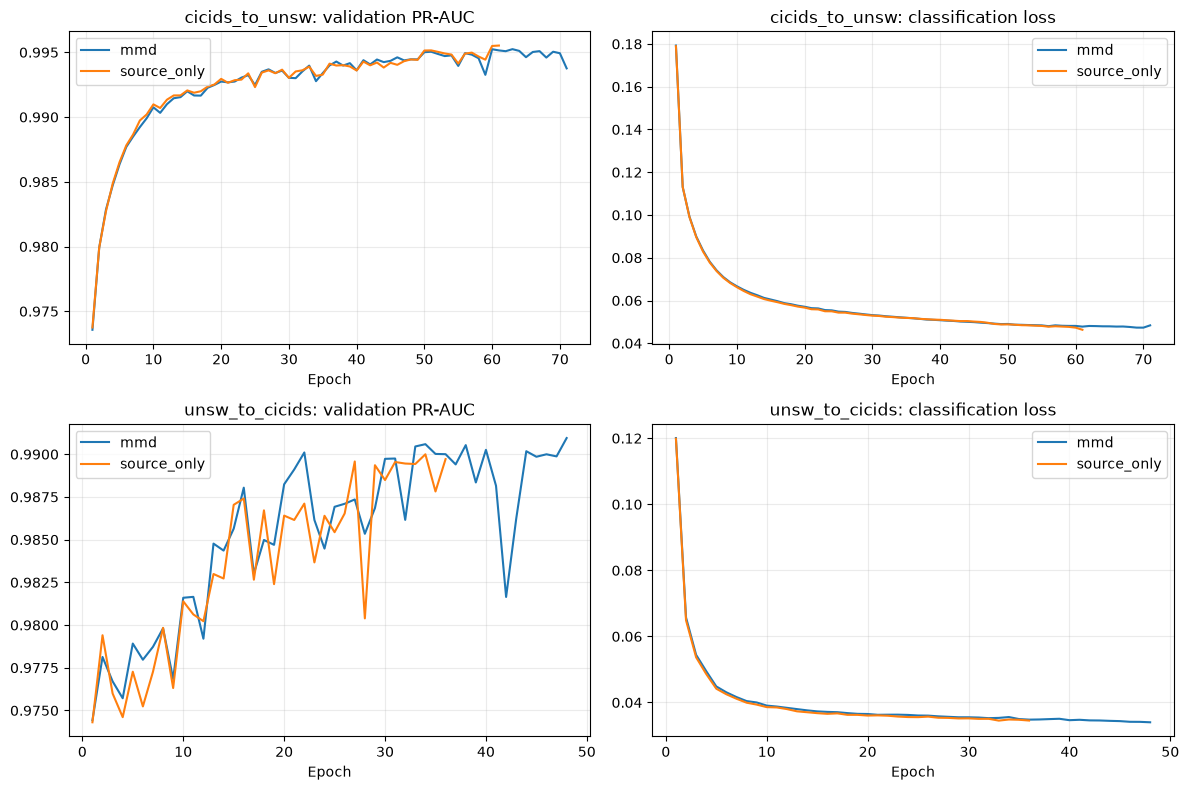

In [20]:
if "rq2_learning_curves" not in tables:
    print("Không có learning curve trong thư mục này.")
else:
    curves = tables["rq2_learning_curves"]
    mean_curves = (
        curves.groupby(["direction", "method", "epoch"], as_index=False)
        [["classification_loss", "mmd_loss", "source_validation_pr_auc"]].mean()
    )
    directions = mean_curves["direction"].unique()
    fig, axes = plt.subplots(len(directions), 2, figsize=(12, 4 * len(directions)), squeeze=False)
    for row, direction in enumerate(directions):
        selected = mean_curves.loc[mean_curves["direction"].eq(direction)]
        for method, group in selected.groupby("method"):
            axes[row, 0].plot(group["epoch"], group["source_validation_pr_auc"], label=method)
            axes[row, 1].plot(group["epoch"], group["classification_loss"], label=method)
        axes[row, 0].set_title(f"{direction}: validation PR-AUC")
        axes[row, 1].set_title(f"{direction}: classification loss")
        for ax in axes[row]:
            ax.set_xlabel("Epoch")
            ax.grid(alpha=0.25)
            ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Kết quả từng seed

In [21]:
per_seed_name = next(
    (name for name in ("rq2_per_seed_metrics", "rq1_per_seed_metrics") if name in tables),
    None,
)
if per_seed_name is None:
    print("Không có bảng per-seed trong thư mục này.")
else:
    per_seed = tables[per_seed_name]
    seed_columns = [
        "direction", "method", "evaluation_domain", "seed",
        "best_epoch", "mmd_lambda", "threshold",
        "pr_auc", "roc_auc", "f1", "recall", "precision",
    ]
    display(per_seed[[column for column in seed_columns if column in per_seed]].round(6))

,direction,method,evaluation_domain,seed,best_epoch,mmd_lambda,threshold,pr_auc,roc_auc,f1,recall,precision
0,unsw_to_cicids,source_only,within_domain,42,16,0.00,0.867232,0.975063,0.997196,0.959002,0.973200,0.945212
1,unsw_to_cicids,source_only,cross_domain,42,16,0.00,0.867232,0.371098,0.528038,0.222594,0.258547,0.195419
2,unsw_to_cicids,mmd,within_domain,42,11,0.01,0.845935,0.989257,0.998854,0.956670,0.961940,0.951457
3,unsw_to_cicids,mmd,cross_domain,42,11,0.01,0.845935,0.374882,0.517661,0.259847,0.312844,0.222204
4,unsw_to_cicids,source_only,within_domain,43,2,0.00,0.780534,0.977550,0.997599,0.945159,0.974614,0.917432
5,unsw_to_cicids,source_only,cross_domain,43,2,0.00,0.780534,0.352202,0.537092,0.250306,0.305984,0.211772
6,unsw_to_cicids,mmd,within_domain,43,33,0.01,0.834496,0.991849,0.998978,0.962400,0.972269,0.952729
7,unsw_to_cicids,mmd,cross_domain,43,33,0.01,0.834496,0.439492,0.530910,0.321695,0.309330,0.335089
8,unsw_to_cicids,source_only,within_domain,44,2,0.00,0.722728,0.970558,0.996842,0.944089,0.988033,0.903887
9,unsw_to_cicids,source_only,cross_domain,44,2,0.00,0.722728,0.213279,0.491064,0.171896,0.202229,0.149476
